# Rating Model

In this notebook i conduct a complete data quality assesment on data about Serie A 2024/2025 season.

## Dependencies & Setup

In [99]:
import pandas as pd
import numpy as np 


import os 
import os.path as osp

import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
import sys
sys.path.append('..')
from src import data_preprocessing as dp


In [3]:
root_folder = osp.split(os.getcwd())[0]
data_folder = osp.join(root_folder, 'data')
data_folder


'e:\\Edoardo\\Education\\SportDataCampus\\SportsDataCampus\\Module4\\tarea_individual\\data'

## Data import

In [12]:
df = pd.read_csv(osp.join(data_folder, 'SerieA_2024_2025.csv'))
df.head()

,id,name,position,shirt_number,team_id,team_side,substitute,captain,total_pass,accurate_pass,...,punches,penalty_conceded,total_offside,total_keeper_sweeper,accurate_keeper_sweeper,hit_woodwork,last_man_tackle,own_goals,penalty_won,error_lead_to_a_goal
0,329175,Pierluigi Gollini,G,95,2702,home,False,False,30.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,807295,Alessandro Vogliacco,D,14,2713,home,False,False,21.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,250547,Mattia Bani,D,13,2715,home,False,False,17.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1001828,Koni De Winter,D,4,2713,home,False,False,31.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,922928,Alessandro Zanoli,M,59,2714,home,False,False,5.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Qulity Assesment

### Number of records with valid ratings

In [15]:
# Data shape
r, c = df.shape
print(f"{r} records representing a player ina given match")

17704 records representing a player ina given match


In [19]:
# Number of records with a rating
rating_column = 'rating'
r_with_rating, c = df.loc[~df[rating_column].isna()].shape
print(f"{r_with_rating} records with a rating, i.e. {(r_with_rating/r)*100:.2f}% of the totals")

11678 records with a rating, i.e. 65.96% of the totals


In [81]:
df['rating'].describe()

count    11678.000000
mean         6.875998
std          0.499732
min          3.000000
25%          6.600000
50%          6.800000
75%          7.100000
max         10.000000
Name: rating, dtype: float64

### Duplicates

In [92]:
# Check for duplicate player-match combinations
duplicates = df.duplicated(subset=['id', 'match_id']).sum()
duplicates

np.int64(0)

### Playing time vs Rating

In [24]:
df_wo_rating = df.loc[df[rating_column].isna()]
df_wo_rating['minutes_played'].fillna(0).describe()

count    6026.000000
mean        0.054431
std         0.352383
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         7.000000
Name: minutes_played, dtype: float64

In [26]:
df_with_rating = df.loc[~df[rating_column].isna()]
df_with_rating['minutes_played'].fillna(0).describe()

count    11678.000000
mean        64.453759
std         29.851725
min          3.000000
25%         35.000000
50%         79.000000
75%         90.000000
max         90.000000
Name: minutes_played, dtype: float64

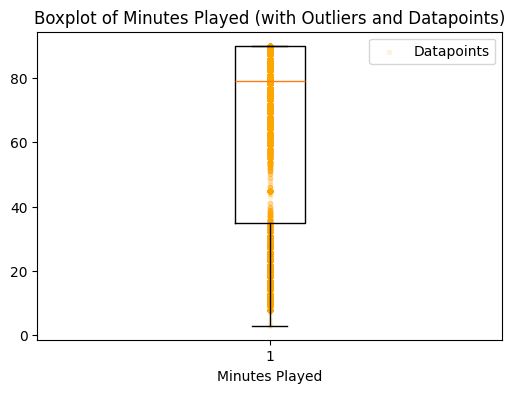

In [34]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_with_rating['minutes_played'].fillna(0), vert=True, showfliers=True)
plt.scatter(
    [1] * len(df_with_rating), 
    df_with_rating['minutes_played'].fillna(0), 
    color='orange', 
    alpha=0.1, 
    s=10, 
    label='Datapoints',
)
plt.xlabel('Minutes Played')
plt.title('Boxplot of Minutes Played (with Outliers and Datapoints)')
plt.legend()
plt.show()

* Minutes played analysis: Median is 79 minutes with 50% of players getting 35-89 minutes.
* High concentration at both ends: many substitutes (0-10 min) and full-match players (70-90 min).
* No extreme outliers beyond 90 minutes, suggesting data quality is good.

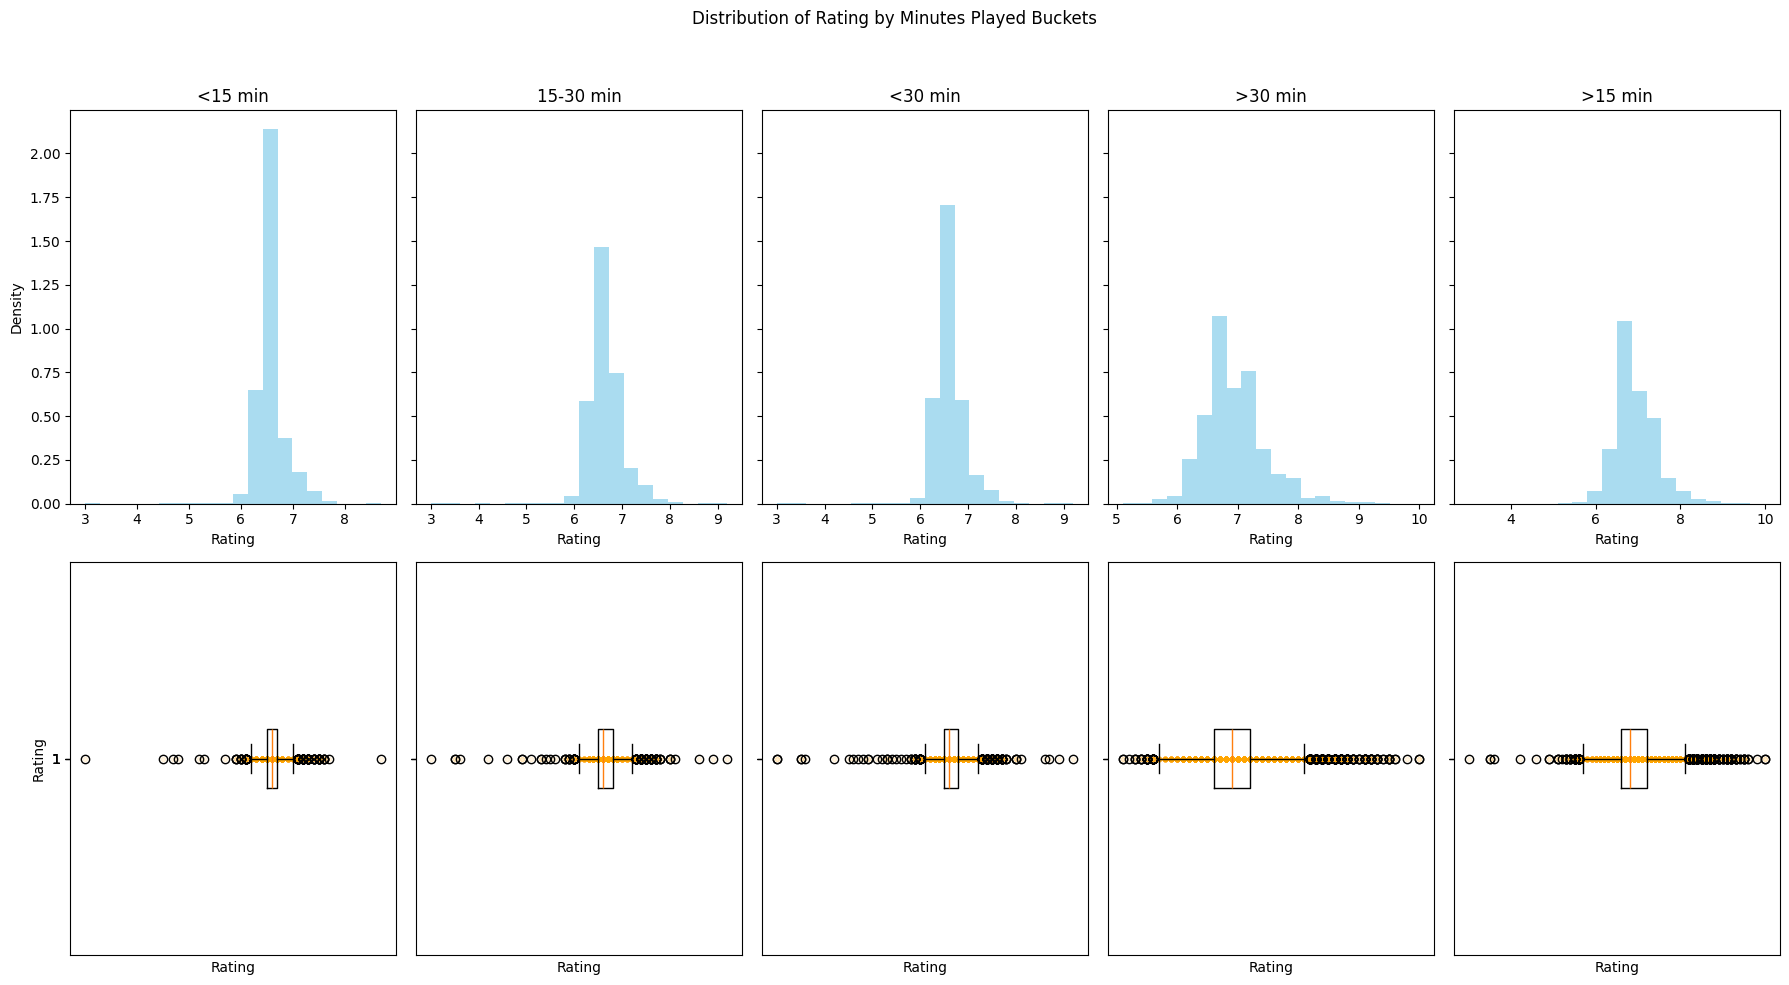

In [50]:
# Distribution of rating for different minutes played buckets

# Define bins
bins = [
    ('<15 min', df_with_rating[df_with_rating['minutes_played'] < 15]['rating']),
    ('15-30 min', df_with_rating[(df_with_rating['minutes_played'] >= 15) & (df_with_rating['minutes_played'] < 30)]['rating']),
    ('<30 min', df_with_rating[df_with_rating['minutes_played'] < 30]['rating']),
    ('>30 min', df_with_rating[df_with_rating['minutes_played'] > 30]['rating']),
    ('>15 min', df_with_rating[df_with_rating['minutes_played'] > 15]['rating']),
]

# First row: histograms, second row: boxplots with datapoints and outliers
fig, axs = plt.subplots(2, len(bins), figsize=(18, 10), sharey='row')

# First row: histograms
for i, (label, data) in enumerate(bins):
    axs[0, i].hist(data, bins=20, alpha=0.7, color='skyblue', density=True)
    axs[0, i].set_title(label)
    axs[0, i].set_xlabel('Rating')
    if i == 0:
        axs[0, i].set_ylabel('Density')

# Second row: boxplots with datapoints and outliers
for i, (label, data) in enumerate(bins):
    axs[1, i].boxplot(data.dropna(), vert=False, showfliers=True)
    axs[1, i].scatter(
        data.dropna(), 
        [1] * len(data.dropna()), 
        color='orange', 
        alpha=0.1, 
        s=10, 
        label='Datapoints'
    )
    axs[1, i].set_xlabel('Rating')
    if i == 0:
        axs[1, i].set_ylabel('Rating')
    axs[1, i].set_xticks([])  # Hide x-tick for boxplot

fig.suptitle('Distribution of Rating by Minutes Played Buckets')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [51]:

stats_list = []
for label, data in bins:
    desc = data.describe(percentiles=[.25, .5, .75])
    stats_list.append({
        'Bin': label,
        'Count': desc['count'],
        'Mean': desc['mean'],
        'Std': desc['std'],
        'Min': desc['min'],
        '25%': desc['25%'],
        'Median': desc['50%'],
        '75%': desc['75%'],
        'Max': desc['max'],
    })
stats_df = pd.DataFrame(stats_list)
stats_df = stats_df.set_index('Bin')
display(stats_df.style.format("{:.2f}"))



,Count,Mean,Std,Min,25%,Median,75%,Max
Bin,,,,,,,,
<15 min,1227.00,6.60,0.29,3.00,6.50,6.60,6.70,8.70
15-30 min,1363.00,6.66,0.40,3.00,6.50,6.60,6.80,9.20
<30 min,2590.00,6.63,0.35,3.00,6.50,6.60,6.80,9.20
>30 min,9016.00,6.95,0.51,5.10,6.60,6.90,7.20,10.00
>15 min,10366.00,6.91,0.51,3.00,6.60,6.80,7.20,10.00


C:\Users\edoar\AppData\Local\Temp\ipykernel_15024\2094535458.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sub_minutes = df_with_rating[df['substitute'] == 1]['minutes_played']


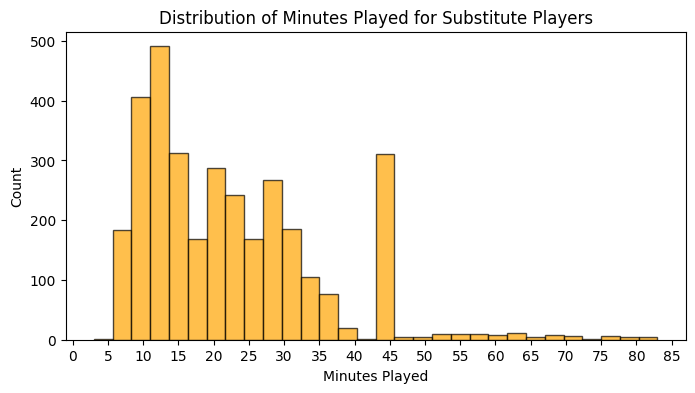

In [52]:
sub_minutes = df_with_rating[df['substitute'] == 1]['minutes_played']
plt.figure(figsize=(8,4))
plt.hist(sub_minutes, bins=30, color='orange', alpha=0.7, edgecolor='k')
plt.title('Distribution of Minutes Played for Substitute Players')
plt.xlabel('Minutes Played')
plt.ylabel('Count')
plt.xticks(ticks=np.arange(0, sub_minutes.max()+5, 5))
plt.show()



In [63]:
substitute_under_15 = df_with_rating[(df_with_rating['substitute'] == 1) & (df_with_rating['minutes_played'] <= 15)].shape[0]
print(f"{substitute_under_15 / len(sub_minutes)*100:.2f}% of all players coming from the bench with rating have less than 15 minutes played")


39.02% of all players coming from the bench with rating have less than 15 minutes played


In [65]:
df_with_rating.columns

Index(['id', 'name', 'position', 'shirt_number', 'team_id', 'team_side',
       'substitute', 'captain', 'total_pass', 'accurate_pass',
       'total_long_balls', 'accurate_long_balls', 'goal_assist',
       'good_high_claim', 'saved_shots_from_inside_the_box', 'saves',
       'minutes_played', 'touches', 'rating', 'possession_lost_ctrl',
       'rating_original', 'rating_alternative', 'goals_prevented', 'match_id',
       'total_cross', 'accurate_cross', 'aerial_lost', 'duel_lost', 'duel_won',
       'dispossessed', 'on_target_scoring_attempt', 'goals', 'total_clearance',
       'outfielder_block', 'interception_won', 'total_tackle', 'fouls',
       'expected_goals', 'expected_assists', 'aerial_won', 'was_fouled',
       'shot_off_target', 'challenge_lost', 'total_contest', 'won_contest',
       'big_chance_created', 'clearance_off_line', 'key_pass',
       'error_lead_to_a_shot', 'big_chance_missed', 'penalty_miss',
       'blocked_scoring_attempt', 'penalty_save', 'punches',
       

In [77]:
# Check key features for subs with <15 min played
features = ['goals', 'error_lead_to_a_goal', 'error_lead_to_a_shot', 'penalty_conceded' ,'own_goals', 'penalty_save' ,'penalty_won', 'penalty_miss', 'goal_assist']
short_match = df_with_rating[(df_with_rating['minutes_played'] <= 15)]
important_events = short_match[features].sum()
print("Key events for subs with <15 min played:\n", important_events)
short_match[short_match[features].sum(axis=1) > 0].shape[0] / len(short_match)

Key events for subs with <15 min played:
 goals                   26.0
error_lead_to_a_goal     3.0
error_lead_to_a_shot     7.0
penalty_conceded         1.0
own_goals                1.0
penalty_save             0.0
penalty_won              3.0
penalty_miss             0.0
goal_assist             21.0
dtype: float64


0.04649390243902439

<Axes: ylabel='Frequency'>

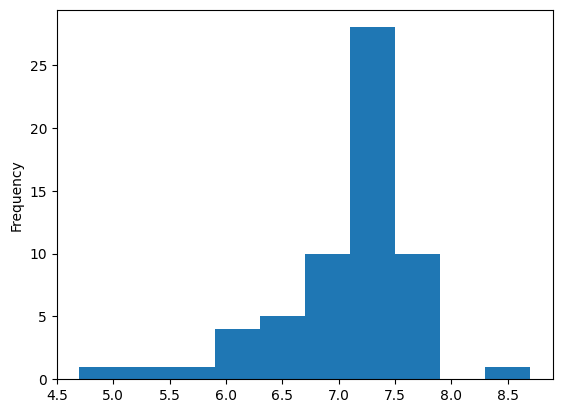

In [79]:
short_match[short_match[features].sum(axis=1) > 0]['rating'].plot.hist()

<Axes: ylabel='Frequency'>

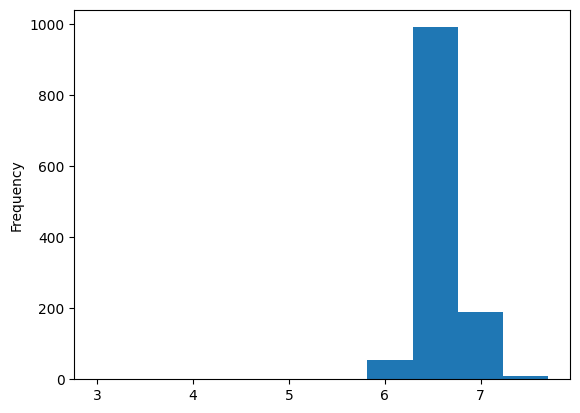

In [80]:
short_match[short_match[features].sum(axis=1) == 0]['rating'].plot.hist()

In fact, players who played less than 15 minutes mainly received a rating of 6.5, which is the base rating on Sofascore. If they received a rating other than 6.5, it is probably because they were involved in an important event.

In [82]:
df_long_match = df_with_rating[(df_with_rating['minutes_played'] > 15)]

### Rating Distribution Analysis

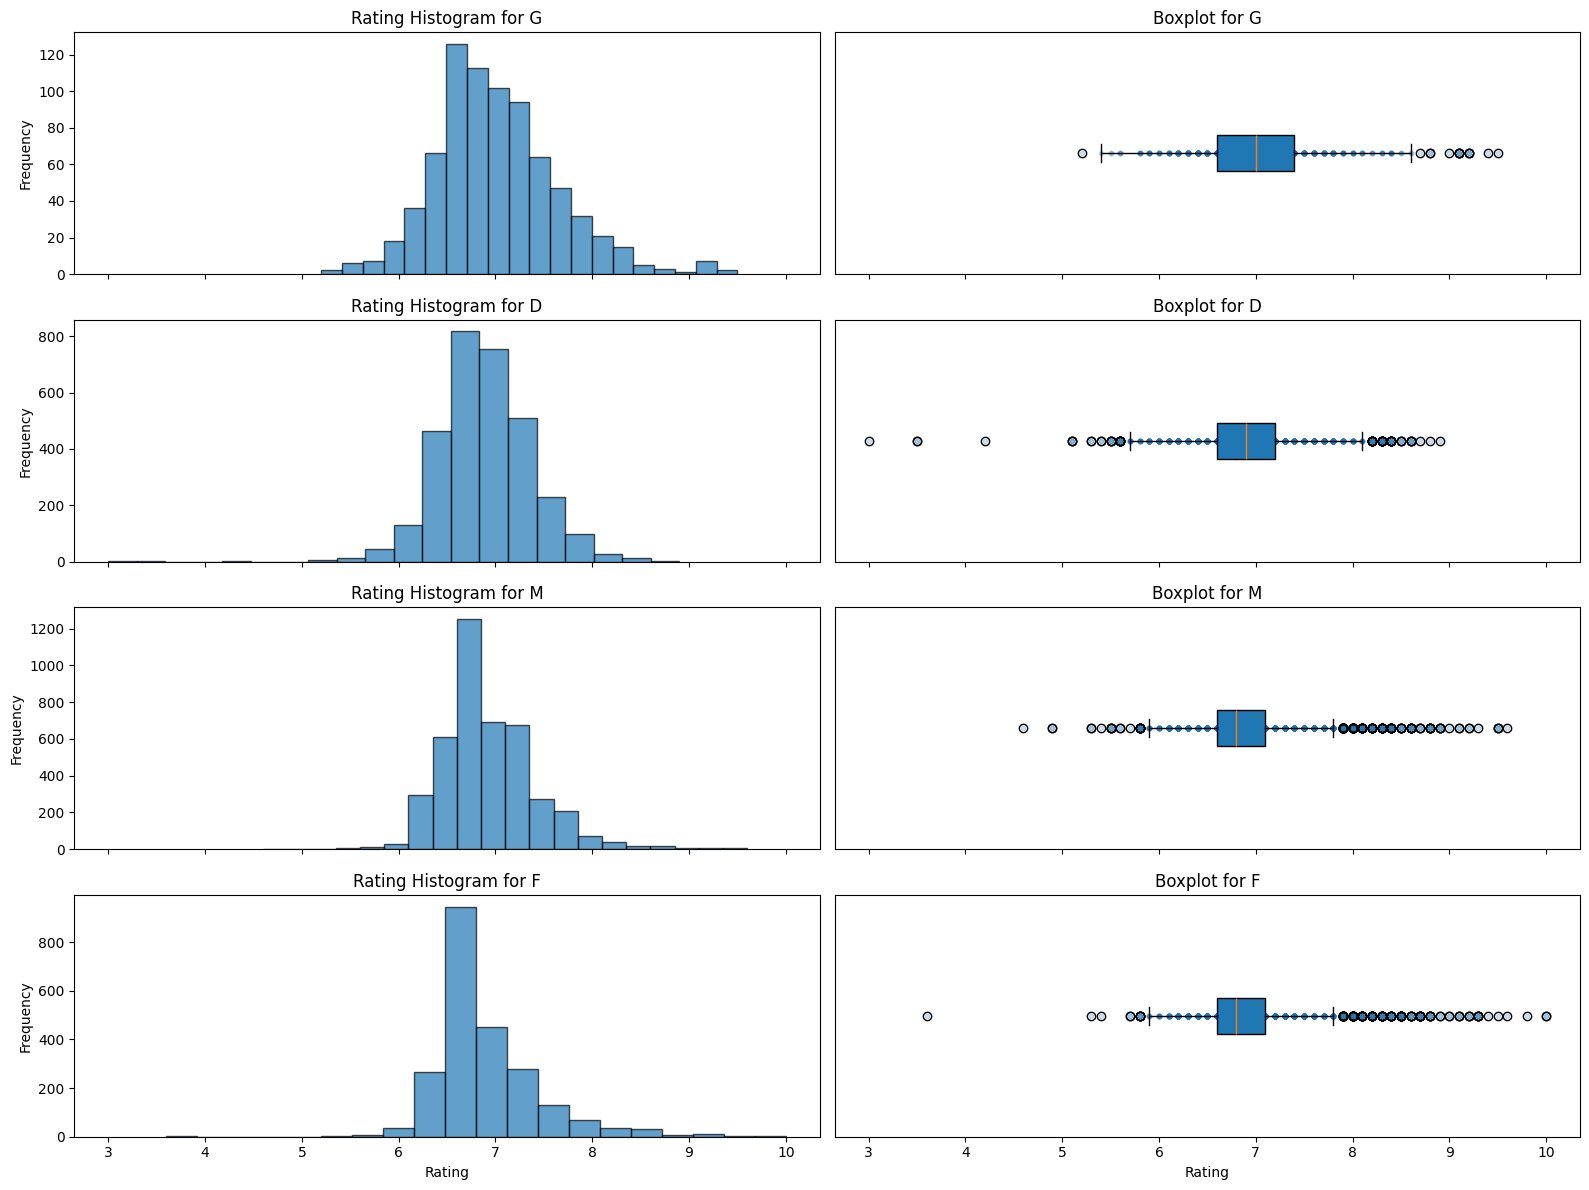

,count,mean,std,min,25%,50%,75%,max
position,,,,,,,,
D,3119.0,6.905835,0.488348,3.0,6.6,6.9,7.2,8.9
F,2276.0,6.911819,0.545057,3.6,6.6,6.8,7.1,10.0
G,767.0,7.017862,0.630911,5.2,6.6,7.0,7.4,9.5
M,4204.0,6.895885,0.477068,4.6,6.6,6.8,7.1,9.6


In [96]:

positions = df_long_match['position'].unique()
n_positions = len(positions)
fig, axes = plt.subplots(n_positions, 2, figsize=(16, 3 * n_positions), sharex='col')

for i, pos in enumerate(positions):
    # Histogram
    ax_hist = axes[i, 0] if n_positions > 1 else axes[0]
    df_long_match[df_long_match['position'] == pos]['rating'].plot.hist(
        ax=ax_hist, bins=20, alpha=0.7, edgecolor='black'
    )
    ax_hist.set_title(f'Rating Histogram for {pos}')
    ax_hist.set_ylabel('Frequency')
    ax_hist.set_xlabel('Rating')

    # Boxplot with datapoints
    ax_box = axes[i, 1] if n_positions > 1 else axes[1]
    data = df_long_match[df_long_match['position'] == pos]['rating']
    ax_box.boxplot(data, vert=False, patch_artist=True, showfliers=True)
    # Overlay datapoints
    ax_box.scatter(data, [1]*len(data), alpha=0.2, color='tab:blue', s=10)
    ax_box.set_title(f'Boxplot for {pos}')
    ax_box.set_yticks([])
    ax_box.set_xlabel('Rating')

plt.tight_layout()
plt.show()

df_long_match.groupby('position')['rating'].describe()


The data shows clear positional differences in rating patterns. Goalkeepers consistently get higher ratings (likely due to fewer players competing for the position), while forwards show the most variance (reflecting the high-impact, high-variance nature of attacking play). This suggests that build separeted models could be a valid option. 

### Conclusion

In [13]:
# Save final filtered dataset
df_long_match = df[df['minutes_played'] > 15].copy()

In [14]:
dp.validate_data_quality(df_long_match)

INFO:src.data_preprocessing:Data quality validation completed


{'total_records': 10366,
 'missing_ratings': np.int64(0),
 'rating_range': (np.float64(3.0), np.float64(10.0)),
 'rating_mean': np.float64(6.911402662550645),
 'rating_std': np.float64(0.5095093981946504),
 'position_distribution': {'M': 4204, 'D': 3119, 'F': 2276, 'G': 767},
 'teams_count': 103,
 'players_count': 563,
 'matches_count': 380}

In [105]:
# Final data quality assessment summary:
# - Total records: 17704 player-match observations
# - Filtered to >15 minutes played: 10366 records (58.55% of original data)
# - Rating distribution: Mean 6.91, Std 0.51, Range 3.0-10.0
# - Position breakdown:  G(7%), D(30%), M(41%), F(22%),
# - Goalkeepers show highest ratings (7.02) with highest variance (0.63)
# - Forwards have widest rating range (3.6-10.0) indicating high-impact variance
# - Data quality is good with no extreme outliers or missing values in key fields

In [ ]:
df_long_match.to_csv(osp.join(data_folder, 'players_stats_filtered.csv'), index=False)
print(f"Final dataset: {len(df_long_match)} records saved")

Final dataset: 10366 records saved


## Data Exploration

In [167]:
df = pd.read_csv(osp.join(data_folder, 'players_stats_filtered.csv'), low_memory=False)

print("shape:", df.shape)
print("columns:", len(df.columns))
display(df.head(3))

# Basic assumptions about meta columns (adjust if needed)
meta_cols = [
    "id", "name", "position", "shirt_number",
    "team_id", "team_side", "substitute", "captain", "match_id"
]

features_cols = [
    c for c in df.columns if (c not in meta_cols and 'rating' not in c)
]

rating_cols = [
        c for c in df.columns if 'rating' in c 
]

shape: (10366, 63)
columns: 63


,id,name,position,shirt_number,team_id,team_side,substitute,captain,total_pass,accurate_pass,...,punches,penalty_conceded,total_offside,total_keeper_sweeper,accurate_keeper_sweeper,hit_woodwork,last_man_tackle,own_goals,penalty_won,error_lead_to_a_goal
0,329175,Pierluigi Gollini,G,95,2702,home,False,False,30.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,807295,Alessandro Vogliacco,D,14,2713,home,False,False,21.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,250547,Mattia Bani,D,13,2715,home,False,False,17.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [168]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    out = (
        frame.isna().sum()
        .to_frame("missing")
        .assign(total=len(frame))
        .assign(pct=lambda d: (d["missing"] / d["total"]).round(4))
        .sort_values("pct", ascending=False)
    )
    return out


miss_df = missing_summary(df)
miss_df.head(30)



,missing,total,pct
penalty_save,10348,10366,0.9983
penalty_miss,10342,10366,0.9977
own_goals,10330,10366,0.9965
clearance_off_line,10301,10366,0.9937
penalty_won,10299,10366,0.9935
last_man_tackle,10278,10366,0.9915
penalty_conceded,10263,10366,0.9901
error_lead_to_a_goal,10255,10366,0.9893
hit_woodwork,10131,10366,0.9773
punches,10123,10366,0.9766


In [169]:
miss_df.tail(30)

,missing,total,pct
expected_goals,5348,10366,0.5159
was_fouled,5190,10366,0.5007
aerial_won,4966,10366,0.4791
aerial_lost,4827,10366,0.4657
fouls,4733,10366,0.4566
total_tackle,4481,10366,0.4323
total_clearance,4246,10366,0.4096
accurate_long_balls,4027,10366,0.3885
expected_assists,2940,10366,0.2836
total_long_balls,2367,10366,0.2283


Most columns contain null values, either because certain features are collected for specific roles (such as features for goalkeepers) or because when a player does not perform any events of that type, instead of having zero, the statistic has not been reported.

We can fill the missing data with zeros. The handle_missing_values method fill the numerical columns with zeros and the categorical ones with "Unknown"

In [170]:
filled_df = dp.handle_missing_values(df)
miss_df = missing_summary(filled_df)
miss_df

INFO:src.data_preprocessing:Filled missing values in 58 numeric and 3 categorical columns


,missing,total,pct
id,0,10366,0.0
name,0,10366,0.0
position,0,10366,0.0
shirt_number,0,10366,0.0
team_id,0,10366,0.0
...,...,...,...
hit_woodwork,0,10366,0.0
last_man_tackle,0,10366,0.0
own_goals,0,10366,0.0
penalty_won,0,10366,0.0


As a next step, we will separate the goalkeepers from the field players.

In [171]:
df = filled_df.copy()
is_gk = df["position"] == "G"
is_out = df["position"].isin(["D", "M", "F"])

# Quick domain check for expected GK signals
gk_features = [c for c in features_cols if any(k in c for k in ["save", "keeper", "punch", "claim", "prevented"])]
print("Likely GK by name:", sorted(gk_features))

Likely GK by name: ['accurate_keeper_sweeper', 'goals_prevented', 'good_high_claim', 'penalty_save', 'punches', 'saved_shots_from_inside_the_box', 'saves', 'total_keeper_sweeper']


In [172]:
out_features = [ c for c in features_cols if c not in gk_features]
out_features

['total_pass',
 'accurate_pass',
 'total_long_balls',
 'accurate_long_balls',
 'goal_assist',
 'minutes_played',
 'touches',
 'possession_lost_ctrl',
 'total_cross',
 'accurate_cross',
 'aerial_lost',
 'duel_lost',
 'duel_won',
 'dispossessed',
 'on_target_scoring_attempt',
 'goals',
 'total_clearance',
 'outfielder_block',
 'interception_won',
 'total_tackle',
 'fouls',
 'expected_goals',
 'expected_assists',
 'aerial_won',
 'was_fouled',
 'shot_off_target',
 'challenge_lost',
 'total_contest',
 'won_contest',
 'big_chance_created',
 'clearance_off_line',
 'key_pass',
 'error_lead_to_a_shot',
 'big_chance_missed',
 'penalty_miss',
 'blocked_scoring_attempt',
 'penalty_conceded',
 'total_offside',
 'hit_woodwork',
 'last_man_tackle',
 'own_goals',
 'penalty_won',
 'error_lead_to_a_goal']

We correctly isolated all the gk features

In [173]:
gk_df = df.loc[is_gk]
out_df = df.loc[is_out, meta_cols+features_cols+rating_cols]

gk_df.shape, out_df.shape

((767, 63), (9599, 63))

### Correlations with rating, split by position

In [174]:
def top_corrs(frame: pd.DataFrame, feature_pool: list[str], target:str,  k: int = 12) -> pd.DataFrame:
    cols = [c for c in feature_pool if c in frame.columns]
    sub = frame[cols + [target]].select_dtypes(include=[np.number]).dropna(subset=[target])
    corrs = sub.corr(numeric_only=True)[target].drop(target)
    return corrs.reindex(corrs.abs().sort_values(ascending=False).index).head(k).to_frame("corr_to_rating")


print("Top GK correlations:")
display(top_corrs(gk_df, features_cols, k=15, target='rating'))

print("Top Outfield correlations:")
display(top_corrs(out_df, out_features, k=15, target='rating'))

Top GK correlations:


,corr_to_rating
goals_prevented,0.741069
saves,0.705394
saved_shots_from_inside_the_box,0.590937
touches,0.336229
error_lead_to_a_goal,-0.255701
good_high_claim,0.238319
duel_won,0.229189
accurate_long_balls,0.211237
was_fouled,0.185457
penalty_save,0.182775


Top Outfield correlations:


,corr_to_rating
goals,0.493224
key_pass,0.428513
on_target_scoring_attempt,0.402296
duel_won,0.392771
touches,0.371444
expected_assists,0.360309
big_chance_created,0.343616
total_pass,0.303280
goal_assist,0.298229
expected_goals,0.298172


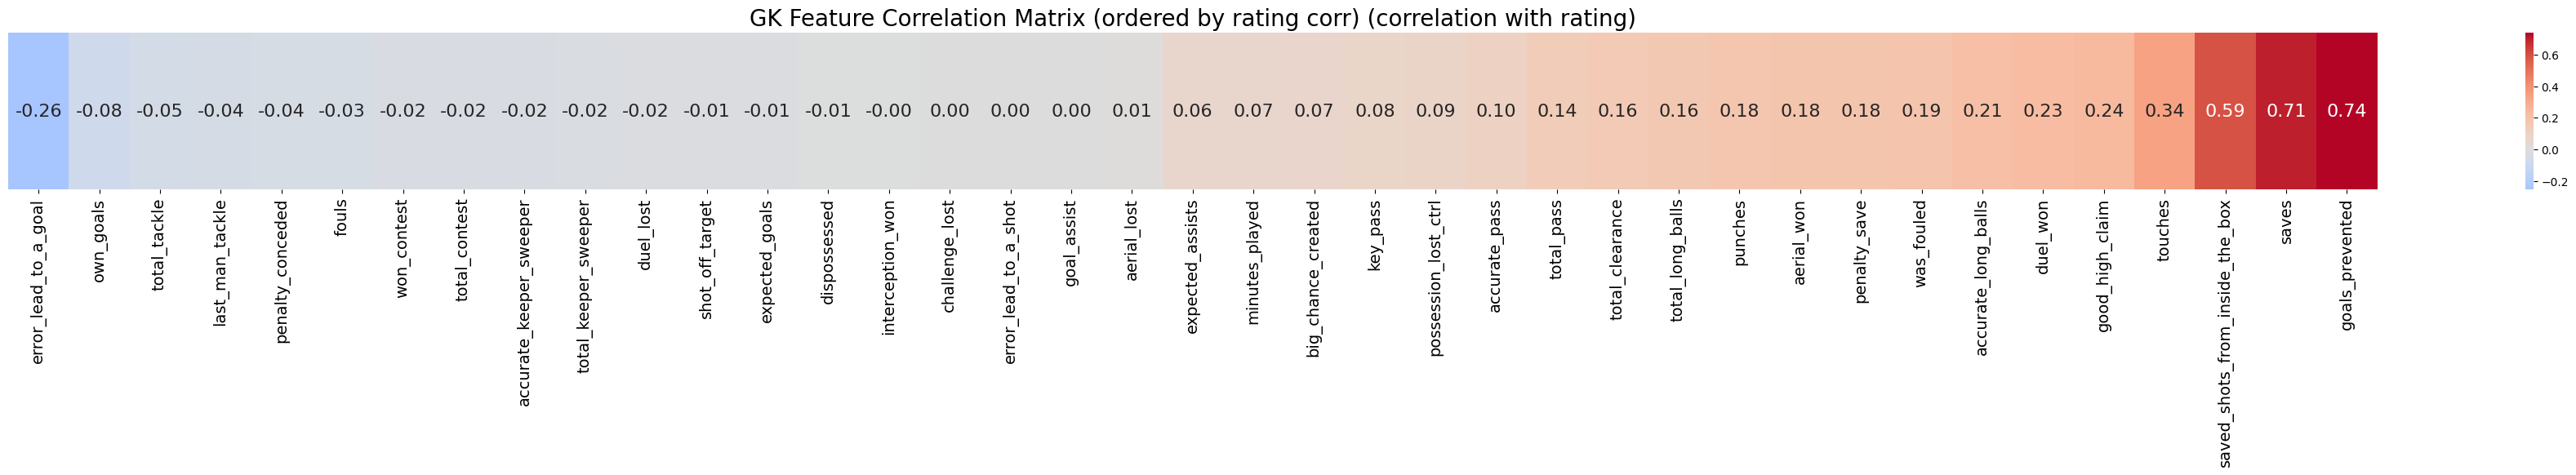

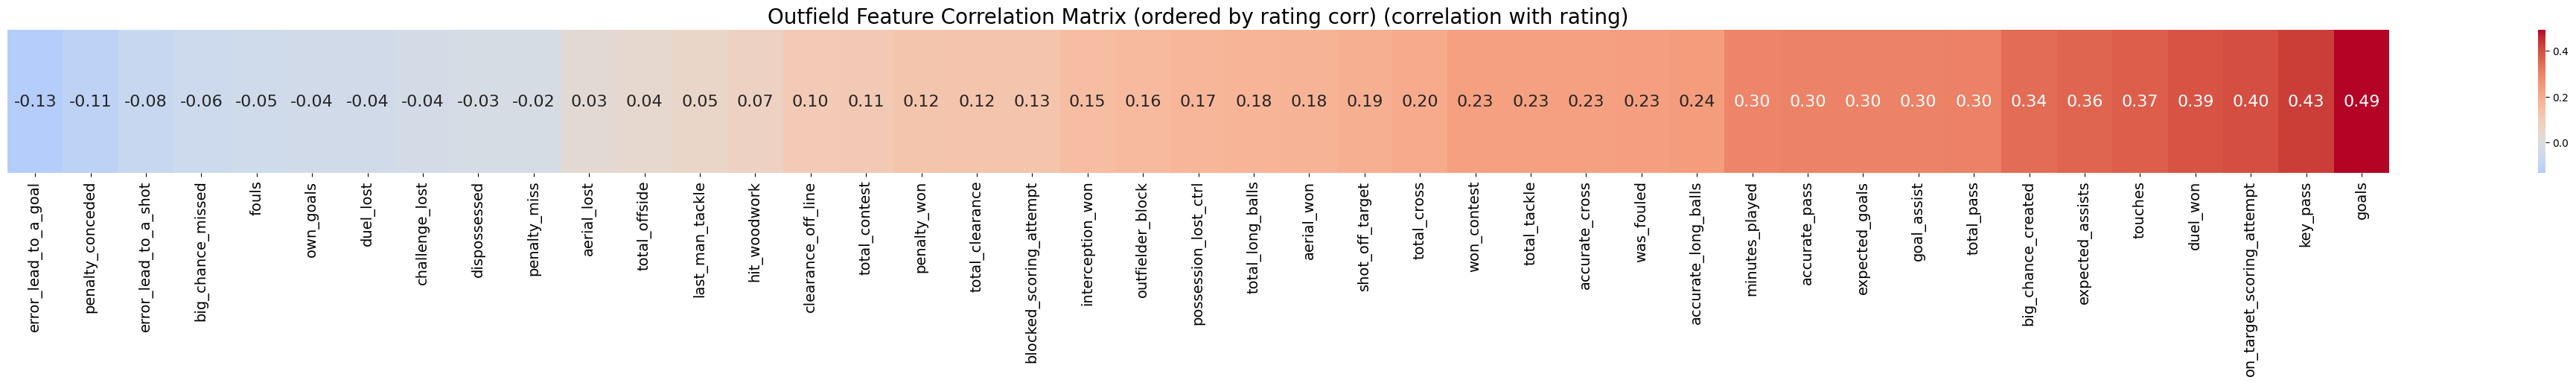

In [108]:
def plot_corr_matrix(df, features, target, title, only_rating_row=False, order_by_target=True):
    cols = [c for c in features if c in df.columns]
    sub = df[cols + [target]].select_dtypes(include=[np.number]).dropna(subset=[target])
    sub = sub.loc[:, (sub != 0).any(axis=0)]
    corr = sub.corr(numeric_only=True)
    if order_by_target:
        order = corr[target].drop(target).sort_values().index.tolist()
    else:
        order = sorted([c for c in corr.columns if c != target])
    ordered_cols = order + [target]
    corr = corr.loc[ordered_cols, ordered_cols]
    
    if only_rating_row:
        if order_by_target:
            corr_row = corr[target].drop(target).sort_values()
        else:
            corr_row = corr[target].drop(target).reindex(order)
        plt.figure(figsize=(1.2*len(corr_row), 2.5))
        sns.heatmap(
            corr_row.to_frame().T,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            cbar=True,
            annot_kws={"fontsize": 16}
        )
        plt.title(title + " (correlation with rating)", fontsize=20)
        plt.yticks([])
        plt.xticks(rotation=90, fontsize=14)
        plt.show()
        return corr_row
    else:
        plt.figure(figsize=(1.2*len(ordered_cols), 1.2*len(ordered_cols)))
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            cbar=True,
            annot_kws={"fontsize": 16}
        )
        plt.title(title, fontsize=20)
        plt.xticks(rotation=90, fontsize=14)
        plt.yticks(rotation=0)
        plt.show()
        return corr

    

_ = plot_corr_matrix(gk_df, features_cols, "rating", "GK Feature Correlation Matrix (ordered by rating corr)", only_rating_row=True)
_ = plot_corr_matrix(out_df, out_features, "rating", "Outfield Feature Correlation Matrix (ordered by rating corr)", only_rating_row=True)



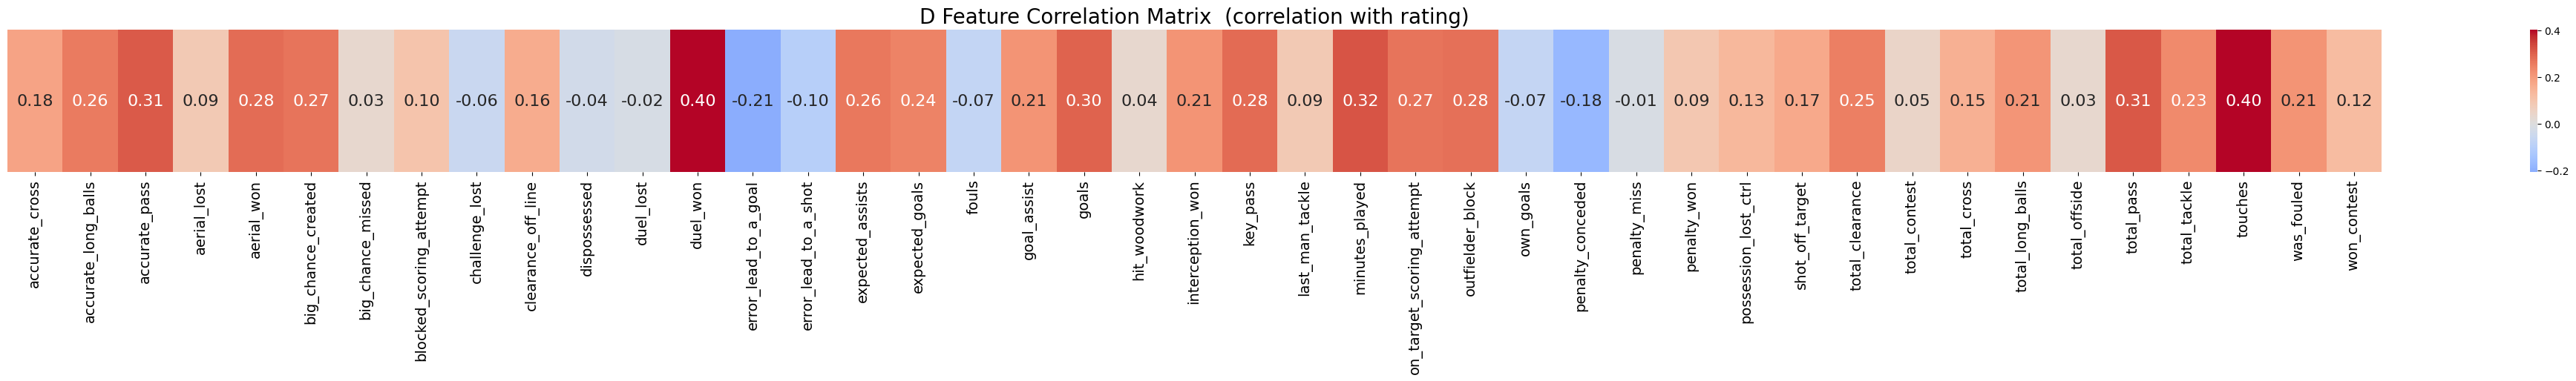

Top 5 abs correlations for D:
duel_won              0.403614
touches               0.400614
minutes_played        0.318920
total_pass            0.313710
accurate_pass         0.308899
goals                 0.296327
key_pass              0.284898
aerial_won            0.279639
outfielder_block      0.275965
big_chance_created    0.269620
Name: D, dtype: float64



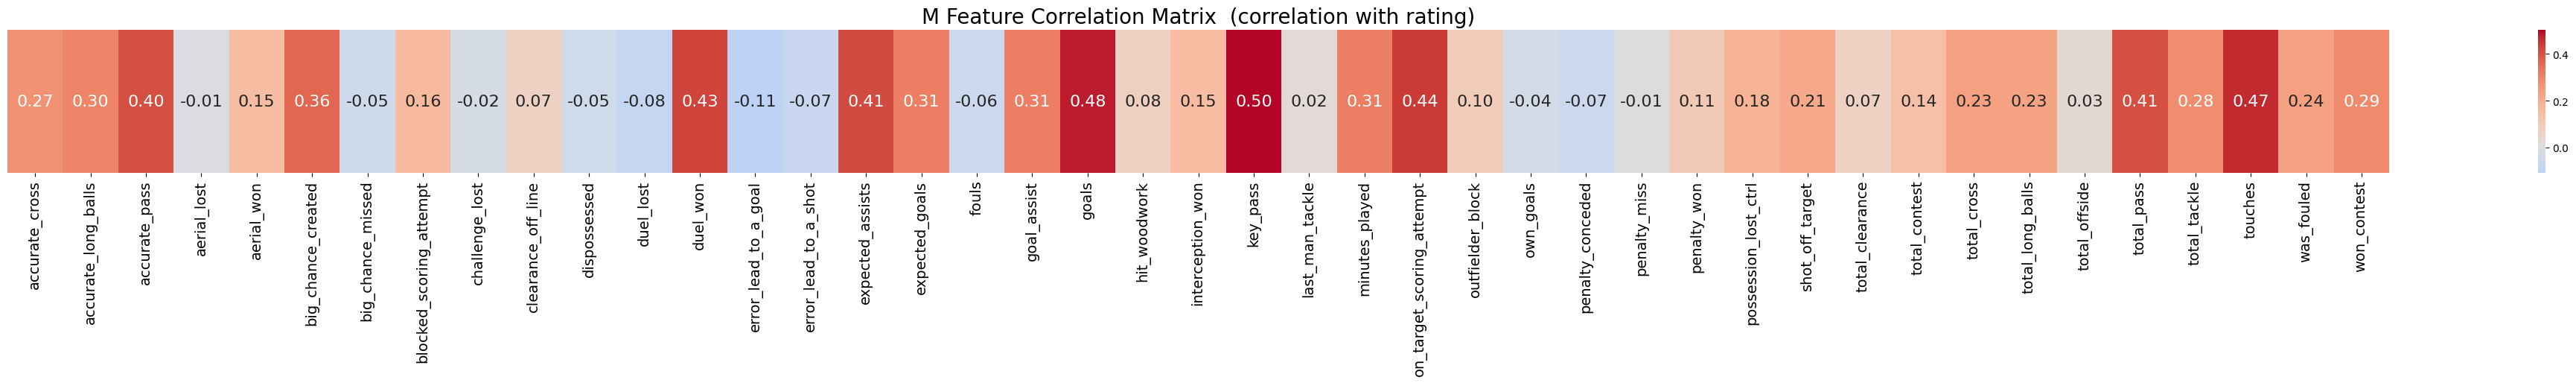

Top 5 abs correlations for M:
key_pass                     0.504030
goals                        0.481379
touches                      0.468094
on_target_scoring_attempt    0.443466
duel_won                     0.426182
expected_assists             0.413241
total_pass                   0.406282
accurate_pass                0.403774
big_chance_created           0.363786
goal_assist                  0.314927
Name: M, dtype: float64



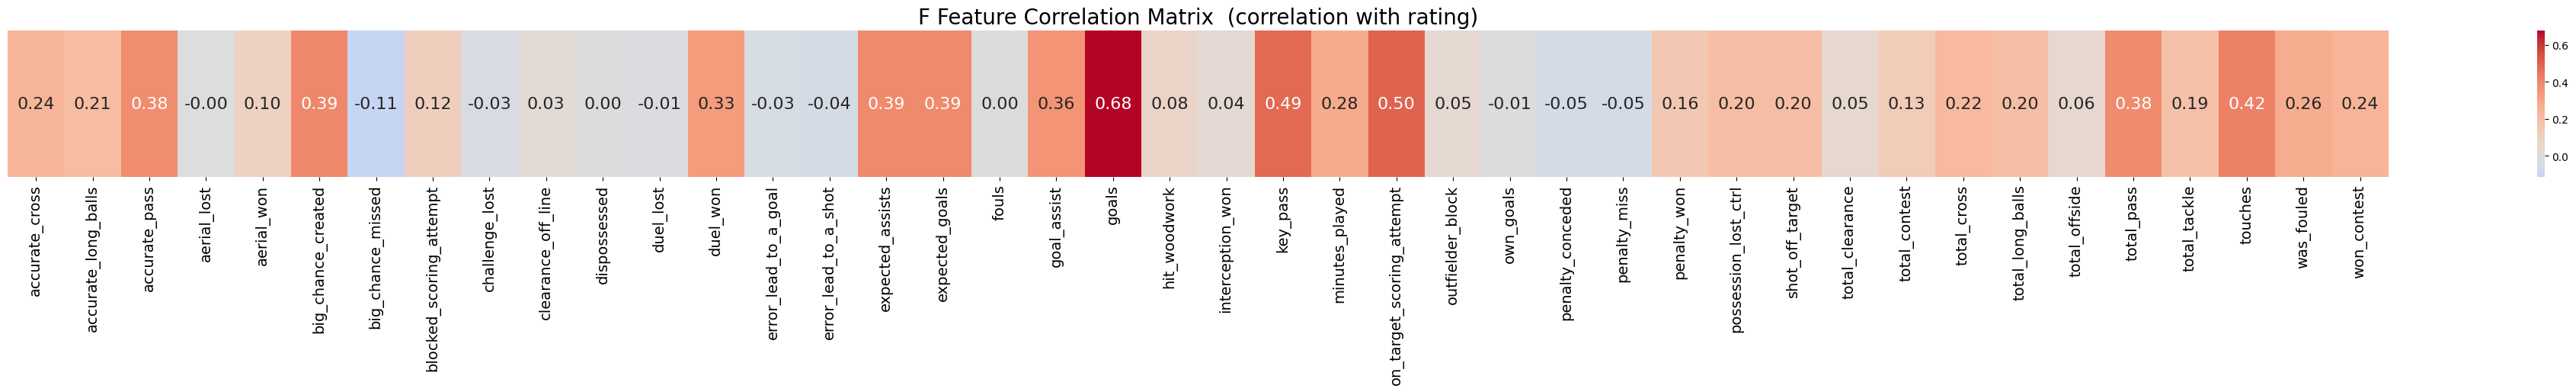

Top 5 abs correlations for F:
goals                        0.679968
on_target_scoring_attempt    0.502044
key_pass                     0.485185
touches                      0.416449
big_chance_created           0.391913
expected_assists             0.389395
expected_goals               0.388572
total_pass                   0.383043
accurate_pass                0.377141
goal_assist                  0.355984
Name: F, dtype: float64



,accurate_cross,accurate_long_balls,accurate_pass,aerial_lost,aerial_won,big_chance_created,big_chance_missed,blocked_scoring_attempt,challenge_lost,clearance_off_line,...,total_clearance,total_contest,total_cross,total_long_balls,total_offside,total_pass,total_tackle,touches,was_fouled,won_contest
D,0.180408,0.257700,0.308899,0.087101,0.279639,0.269620,0.032810,0.102789,-0.059183,0.162713,...,0.249311,0.047398,0.150790,0.209875,0.032804,0.313710,0.229772,0.400614,0.212454,0.124712
M,0.272082,0.300990,0.403774,-0.007407,0.150727,0.363786,-0.052152,0.158907,-0.024479,0.068694,...,0.067259,0.138863,0.234857,0.226899,0.027256,0.406282,0.283438,0.468094,0.235917,0.287120
F,0.237291,0.208137,0.377141,-0.002999,0.097976,0.391913,-0.113815,0.116658,-0.028518,0.031814,...,0.049259,0.128469,0.216499,0.198468,0.055311,0.383043,0.185936,0.416449,0.264773,0.241462


In [111]:
out_roles = ['D', 'M', 'F']

correlations = []
for r in out_roles:
    corr = plot_corr_matrix(
        out_df.loc[out_df['position'] == r],
        out_features,
        "rating",
        f"{r} Feature Correlation Matrix ",
        only_rating_row=True,
        order_by_target=False
    )
    corr.name = r
    # Print top 5 features by absolute correlation with rating
    top5 = corr.abs().sort_values(ascending=False).head(10)
    print(f"Top 5 abs correlations for {r}:")
    print(top5)
    print()
    correlations.append(corr)

pd.DataFrame(correlations)


*Goalkeepers*: goals_prevented, saves, and inside‑box saves dominate. Moderate positives from involvement and aerial control. Distribution helps a bit but is secondary. Big negative is costly mistakes: error_lead_to_a_goal drags ratings meaningfully, as expected.

*Defenders*: Ratings reward defensive actions won and high involvement on the ball (touches/passing). Costly errors are heavily punished. Some weight on progressive distribution (long balls, crosses) → fullbacks benefit.

*Midfielders*: Creation + end-product drive ratings, with ball-dominance and duel success close behind.

*Forwards*: Ratings are highly outcome-weighted for strikers (finishing first, shot quality/volume second), but still give credit for link-up and creation.

Based on these correlations with the rating, it is plausible that creating custom models for each role will lead to greater accuracy.

### Features selection

In [140]:
def high_corr_pairs(
    frame: pd.DataFrame,
    features: list[str],
    position: str | list[str] | None = None,
    threshold: float = 0.85,
    min_nonnull_share: float = 0.05,
    keep_top: int | None = None,
) -> pd.DataFrame:
    """Return table of highly correlated feature pairs with sign and |corr|."""
    if position is not None:
        pos_vals = [position] if isinstance(position, str) else list(position)
        frame = frame[frame["position"].isin(pos_vals)]


    if not features:
        return pd.DataFrame(columns=["feature_1", "feature_2", "corr", "abs_corr"])

    sub = frame[features]
    sub = sub.loc[:, (sub != 0).any(axis=0)]  # drop all-zero columns
    nonnull_share = sub.notna().mean()
    sub = sub.loc[:, nonnull_share >= min_nonnull_share]
    # drop (near-)constant columns
    std = sub.std(numeric_only=True)
    sub = sub.loc[:, std > 0]

    if sub.shape[1] < 2:
        return pd.DataFrame(columns=["feature_1", "feature_2", "corr", "abs_corr"])

    corr = sub.corr(numeric_only=True)

    # take upper triangle without diagonal to avoid duplicates
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    corr_ut = corr.where(mask)

    pairs = (
        corr_ut.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
    )
    pairs["abs_corr"] = pairs["corr"].abs()
    pairs = pairs[pairs["abs_corr"] >= threshold].sort_values("abs_corr", ascending=False)
    if keep_top is not None:
        pairs = pairs.head(keep_top)
    return pairs

In [160]:
pairs_all = high_corr_pairs(df, features=features_cols, threshold=0.5, keep_top=50)
display(pairs_all)

,feature_1,feature_2,corr,abs_corr
1254,total_keeper_sweeper,accurate_keeper_sweeper,0.985562,0.985562
0,total_pass,accurate_pass,0.985060,0.985060
8,total_pass,touches,0.953706,0.953706
57,accurate_pass,touches,0.928667,0.928667
285,saved_shots_from_inside_the_box,saves,0.925182,0.925182
99,total_long_balls,accurate_long_balls,0.856392,0.856392
1085,total_contest,won_contest,0.794934,0.794934
534,total_cross,accurate_cross,0.732875,0.732875
372,minutes_played,touches,0.664126,0.664126
609,aerial_lost,duel_lost,0.623164,0.623164


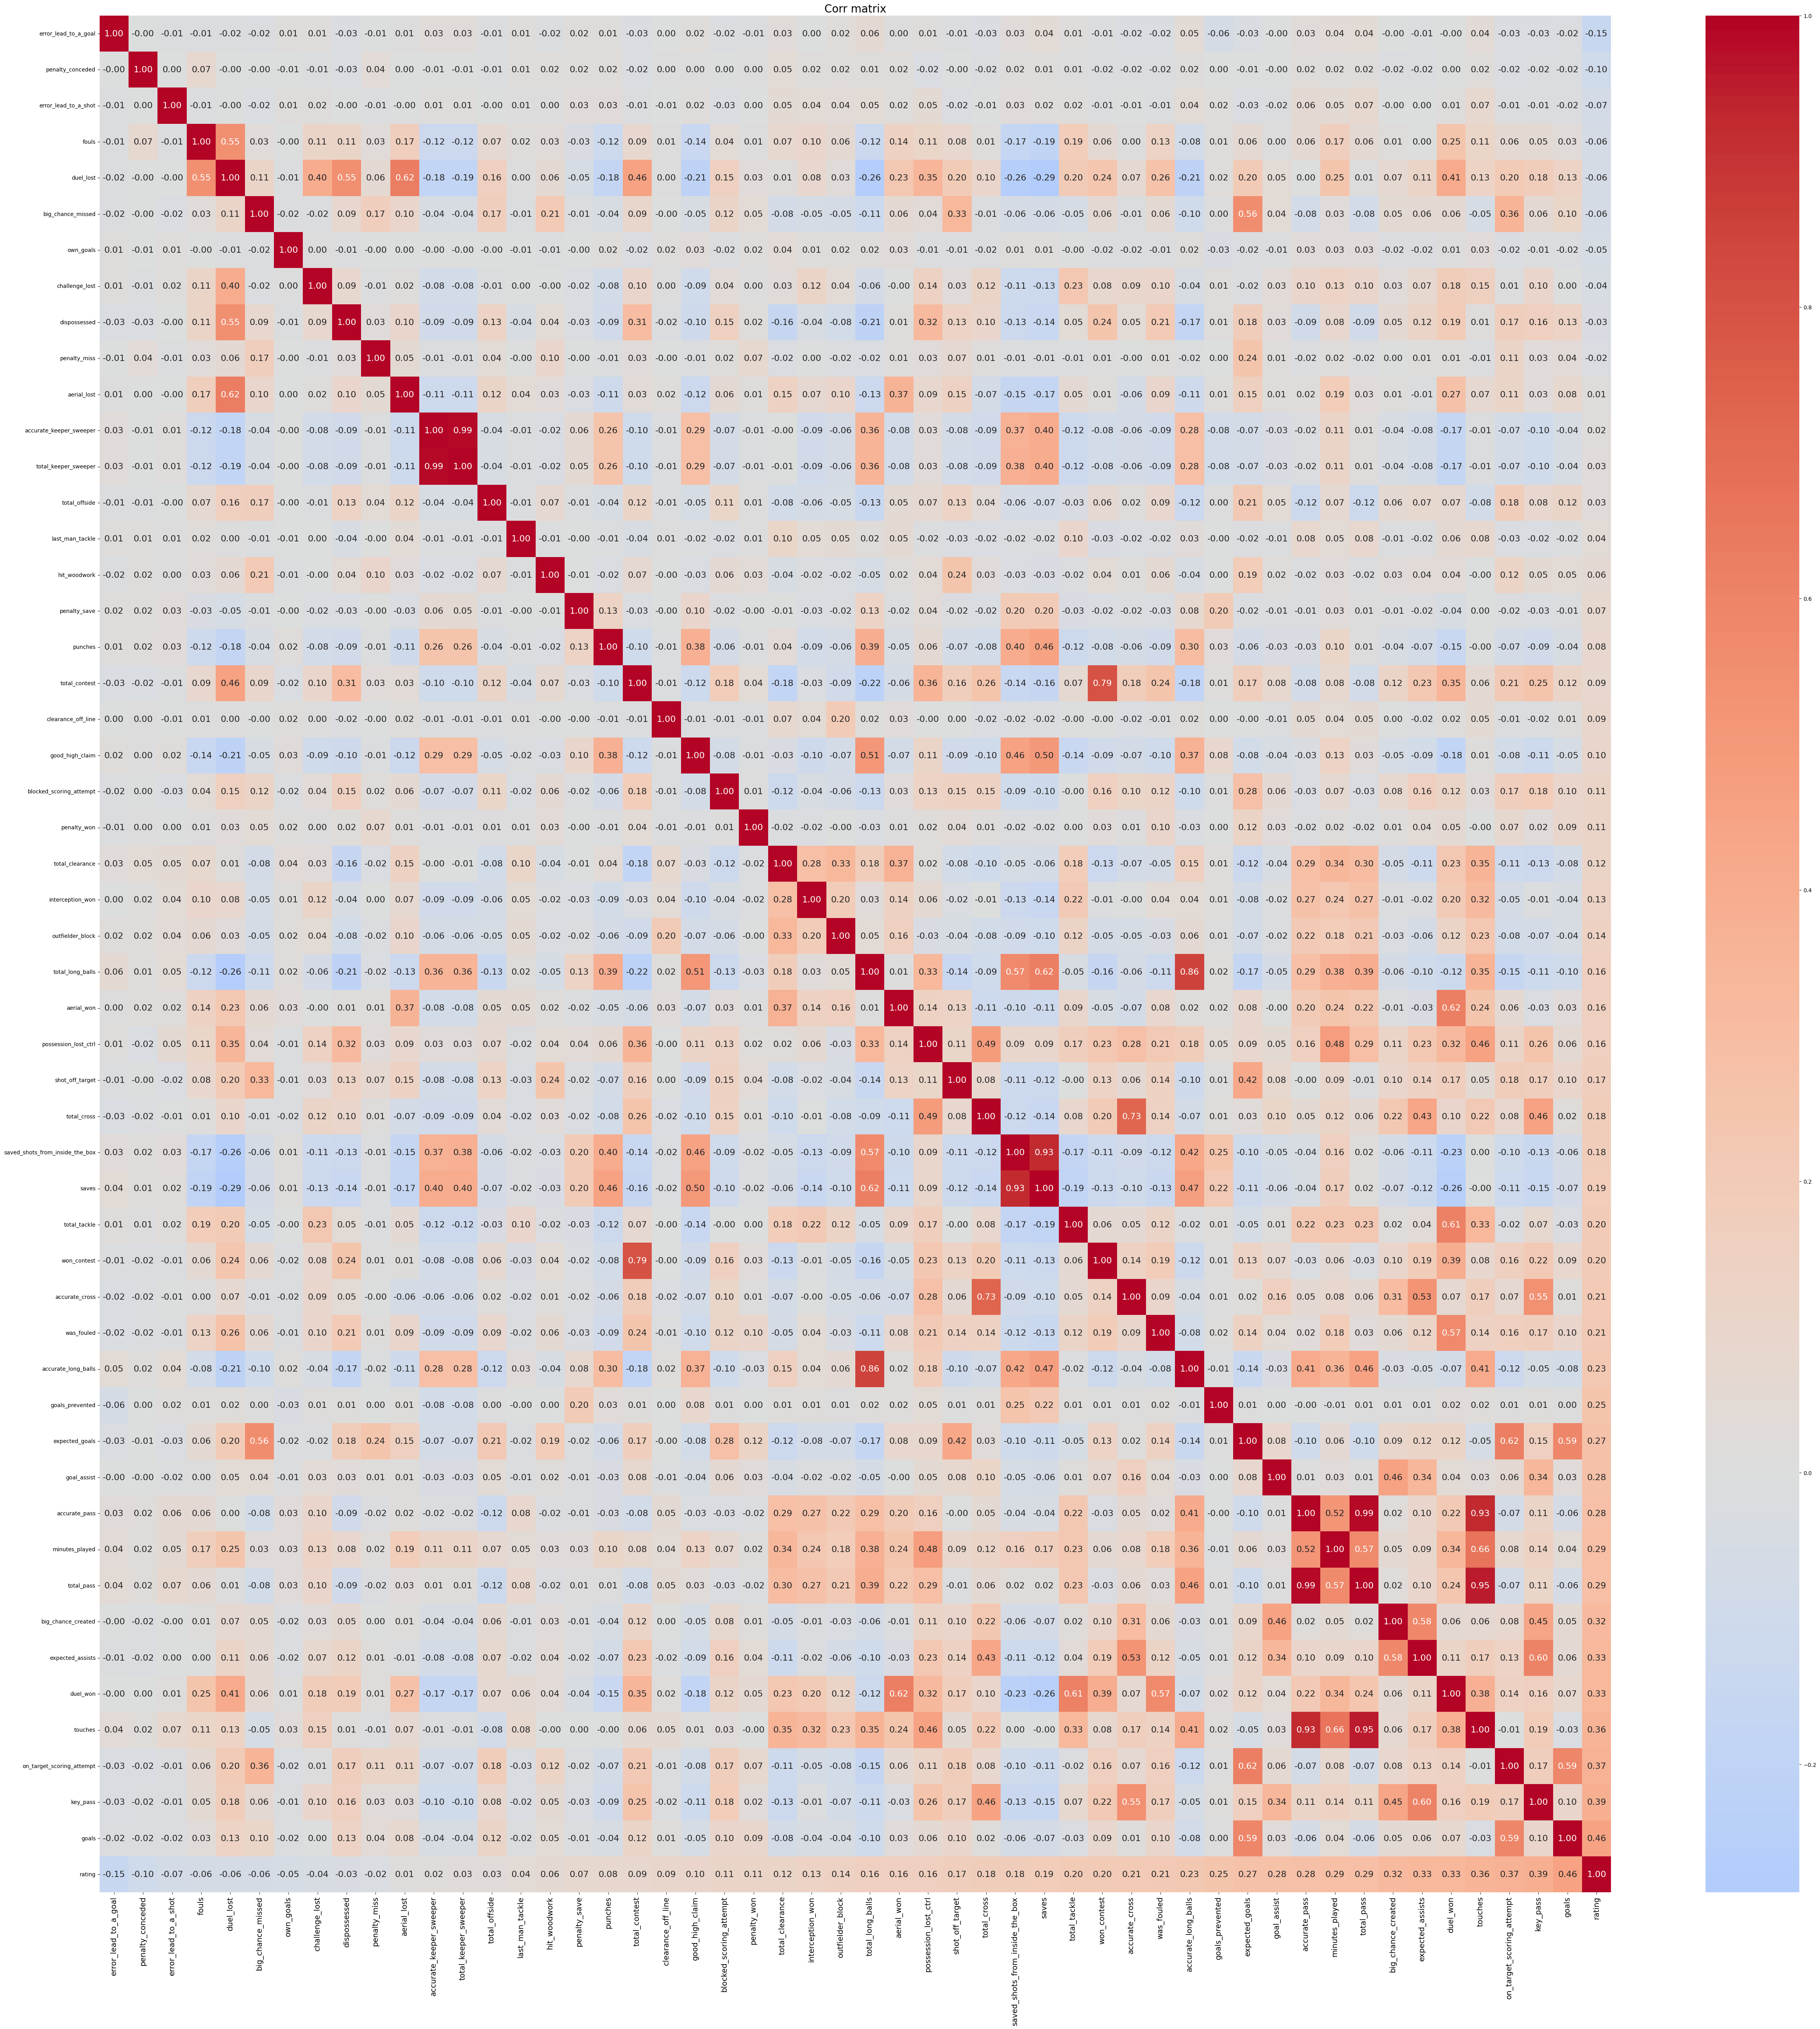

In [146]:
_ = plot_corr_matrix(df=df, features=features_cols, target='rating', title='Corr matrix')

There are some pairs of features that could be reduced to a single ratio, such as total_passes and accurate_passes.

Let's create this ratio and analyze the relationship with the rating and other features.

In [180]:
ACCURACY_SPECS = {
    # Accuracy
    "pass_accuracy": {"num": ["accurate_pass"], "den": ["total_pass"]},
    "long_ball_accuracy": {"num": ["accurate_long_balls"], "den": ["total_long_balls"]},
    "cross_accuracy": {"num": ["accurate_cross"], "den": ["total_cross"]},
    "keeper_sweeper_accuracy": {"num": ["accurate_keeper_sweeper"], "den": ["total_keeper_sweeper"]},
}

DUELS_SPEC = {
    # Duels / contests
    "contest_win_rate": {"num": ["won_contest"], "den": ["total_contest"]},
    "contest_loss_rate": {"num": ["challenge_lost"], "den": ["total_contest"]},
    "duel_win_rate": {"num": ["duel_won"], "den": ["duel_won", "duel_lost"]},
    "aerial_win_rate": {"num": ["aerial_won"], "den": ["aerial_won", "aerial_lost"]},
}


In [187]:

def compute_ratio(row, num_cols, den_cols, fill=np.nan):
    num = sum([row[c] for c in num_cols])
    den = sum([row[c] for c in den_cols])
    if pd.isna(den) or den == 0:
        return fill
    return num / den

ratios = []

for r, spec in ACCURACY_SPECS.items():
    df[r] = df.apply(lambda row: compute_ratio(row, spec["num"], spec["den"],fill=0), axis=1,)
    ratios.append(r)

for r, spec in DUELS_SPEC.items():
    df[r] = df.apply(lambda row: compute_ratio(row, spec["num"], spec["den"], fill=0), axis=1, )
    ratios.append(r)



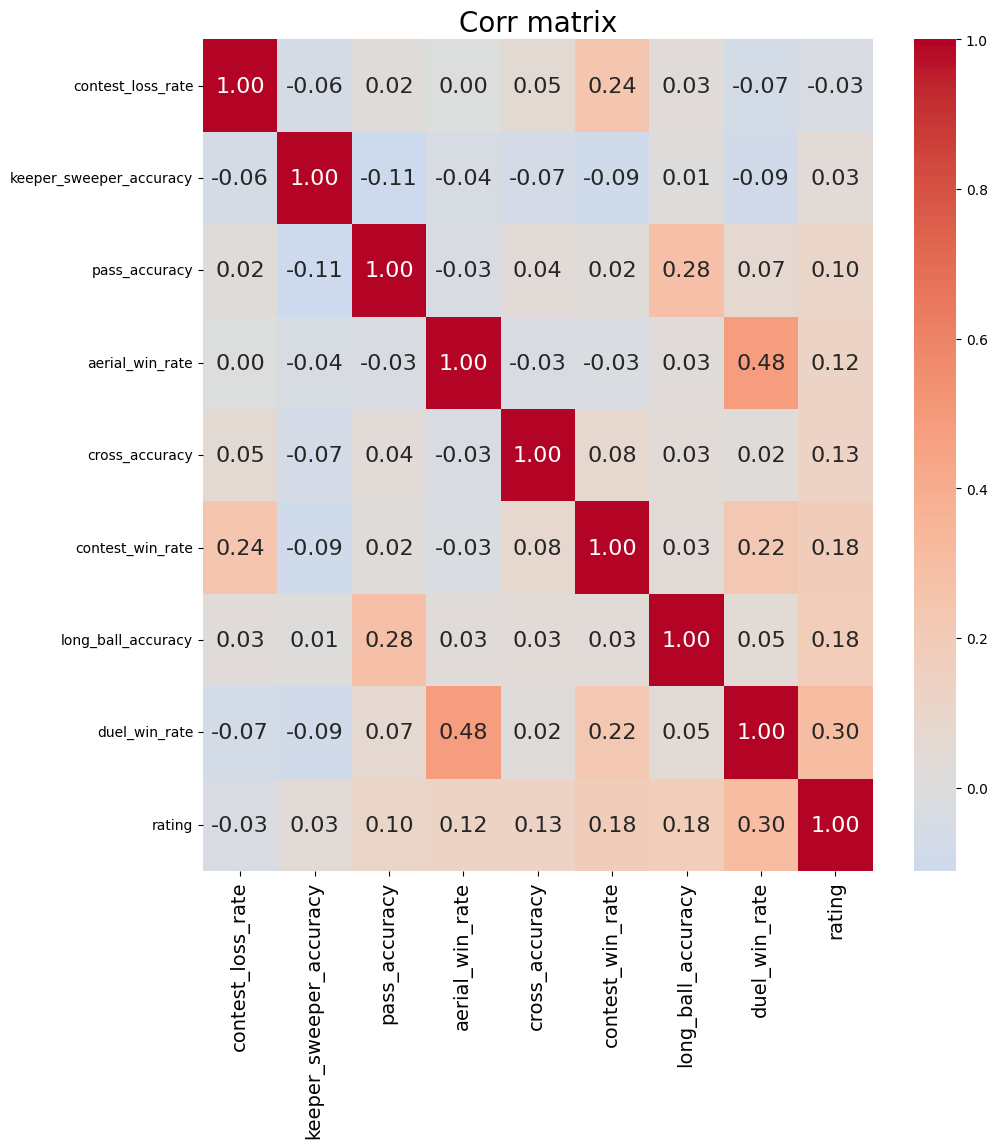

,contest_loss_rate,keeper_sweeper_accuracy,pass_accuracy,aerial_win_rate,cross_accuracy,contest_win_rate,long_ball_accuracy,duel_win_rate,rating
contest_loss_rate,1.000000,-0.057636,0.020019,0.000576,0.053354,0.237271,0.028248,-0.068570,-0.030866
keeper_sweeper_accuracy,-0.057636,1.000000,-0.111519,-0.042426,-0.067637,-0.091062,0.013913,-0.089272,0.032981
pass_accuracy,0.020019,-0.111519,1.000000,-0.029219,0.035242,0.022857,0.283128,0.065393,0.101371
aerial_win_rate,0.000576,-0.042426,-0.029219,1.000000,-0.031679,-0.026947,0.030515,0.477773,0.124974
cross_accuracy,0.053354,-0.067637,0.035242,-0.031679,1.000000,0.078384,0.033646,0.019405,0.129493
contest_win_rate,0.237271,-0.091062,0.022857,-0.026947,0.078384,1.000000,0.034860,0.223949,0.175463
long_ball_accuracy,0.028248,0.013913,0.283128,0.030515,0.033646,0.034860,1.000000,0.047991,0.183282
duel_win_rate,-0.068570,-0.089272,0.065393,0.477773,0.019405,0.223949,0.047991,1.000000,0.298890
rating,-0.030866,0.032981,0.101371,0.124974,0.129493,0.175463,0.183282,0.298890,1.000000


In [188]:
plot_corr_matrix(df=df, features=ratios, target='rating', title='Corr matrix', only_rating_row=False, order_by_target=True)

Now that we have built these ratio, we can inpsect the new correlations

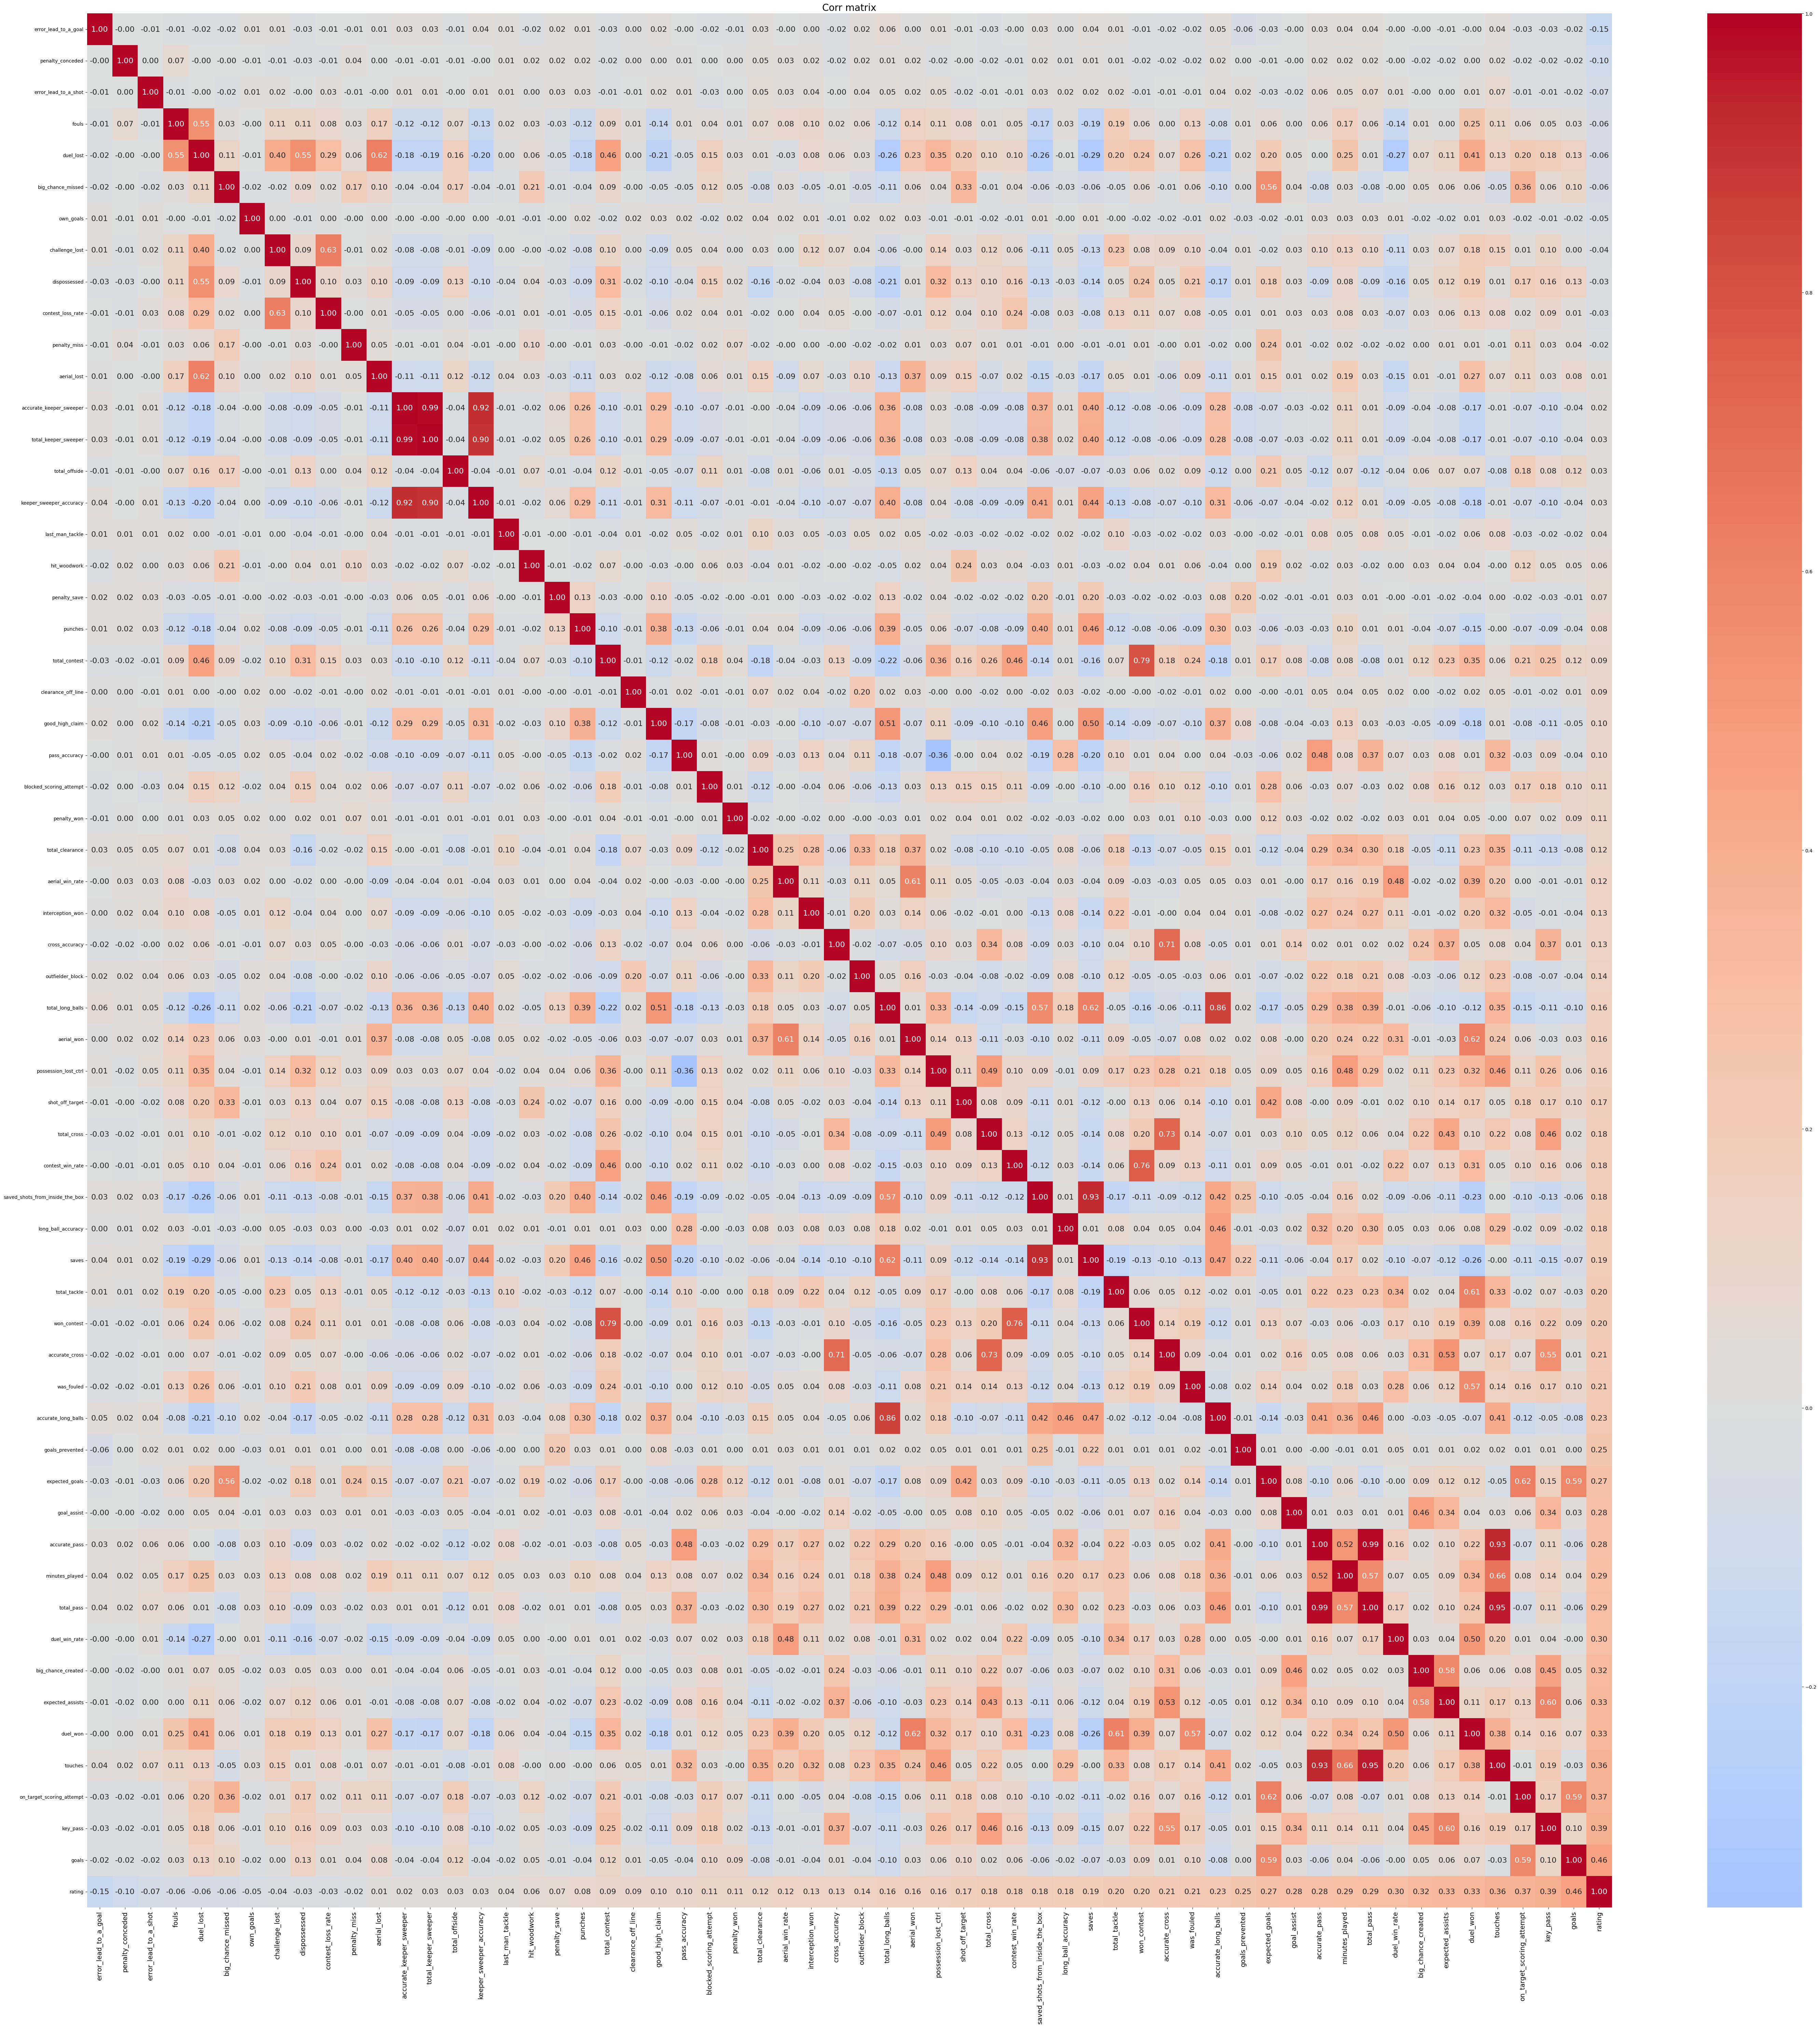

In [189]:
_ = plot_corr_matrix(df=df, features=features_cols+ratios, target='rating', title='Corr matrix')

In [ ]:
cols_to_remove = set()
for spec in A.values():
    cols_to_remove.update(spec["num"])
    cols_to_remove.update(spec["den"])
for _df in [df, gk_df, out_df]:
    if _df is not None:
        _df.drop(columns=list(cols_to_remove), errors="ignore", inplace=True)



C:\Users\edoar\AppData\Local\Temp\ipykernel_17244\3406641165.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df.drop(columns=list(cols_to_remove), errors="ignore", inplace=True)


In [165]:


features_cols = [c for c in features_cols if c not in cols_to_remove]
gk_features = [c for c in gk_features if c not in cols_to_remove]


In [ ]:
pairs_all = high_corr_pairs(df, features=features_cols, threshold=0.5, keep_top=50)
display(pairs_all)

,feature_1,feature_2,corr,abs_corr
69,saved_shots_from_inside_the_box,saves,0.925182,0.925182
134,minutes_played,touches,0.664126,0.664126
285,on_target_scoring_attempt,expected_goals,0.620049,0.620049
463,expected_assists,key_pass,0.604810,0.604810
279,on_target_scoring_attempt,goals,0.589192,0.589192
310,goals,expected_goals,0.588587,0.588587
461,expected_assists,big_chance_created,0.581608,0.581608
447,expected_goals,big_chance_missed,0.557467,0.557467
36,good_high_claim,saves,0.502619,0.502619


The number of pairs

### GK

In [117]:
pairs_gk = high_corr_pairs(gk_df, features=features_cols, position="G", threshold=0.5, keep_top=50)
display(pairs_gk)

,feature_1,feature_2,corr,abs_corr
663,total_contest,won_contest,1.000000,1.000000
573,expected_goals,shot_off_target,1.000000,1.000000
731,total_keeper_sweeper,accurate_keeper_sweeper,0.980242,0.980242
8,total_pass,touches,0.928769,0.928769
82,total_long_balls,possession_lost_ctrl,0.903645,0.903645
564,fouls,penalty_conceded,0.842918,0.842918
448,duel_won,aerial_won,0.839017,0.839017
213,saved_shots_from_inside_the_box,saves,0.828948,0.828948
0,total_pass,accurate_pass,0.800199,0.800199
45,accurate_pass,touches,0.719053,0.719053


In [134]:
import numpy as np
import pandas as pd



def select_non_redundant_features(
    df: pd.DataFrame,
    features: list[str],
    position: str | list[str] | None = None,
    target: str = "rating",
    threshold: float = 0.85,
    min_nonnull_share: float = 0.05,
) -> tuple[list[str], list[str], pd.Series, list[str]]:
    # filter by position if provided
    d = df if position is None else df[df["position"].isin([position] if isinstance(position, str) else position)]

    if not features:
        return [], [], pd.Series(dtype=float), []

    sub = d[features].copy()
    # drop all-zero, sparse, or constant columns
    sub = sub.loc[:, (sub != 0).any(axis=0)]
    nonnull = sub.notna().mean()
    sub = sub.loc[:, nonnull >= min_nonnull_share]
    std = sub.std(numeric_only=True)
    sub = sub.loc[:, std > 0]
    features = list(sub.columns)
    if len(features) < 2 or target not in d.columns:
        return features, [], pd.Series(dtype=float), []

    # feature↔feature corr
    corr_ff = sub.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr_ff, dtype=bool), 1)
    pairs = corr_ff.where(mask).stack().abs().sort_values(ascending=False)

    # feature↔target corr (absolute)
    tgt_corr = d[features + [target]].corr(numeric_only=True)[target].drop(target).abs()

    keep, dropped = set(features), set()
    log = []
    for (a, b), r in pairs.items():
        if r < threshold:
            break
        if a not in keep or b not in keep:
            continue

        ca, cb = tgt_corr.get(a, np.nan), tgt_corr.get(b, np.nan)
        # decide which to drop: lower |corr to target|; tie-break by completeness
        if np.isnan(ca) and np.isnan(cb):
            drop = a if nonnull[a] < nonnull[b] else b
            reason = "both NaN corr to target, drop less complete"
        elif np.isnan(ca):
            drop = a
            reason = f"{a} NaN corr to target"
        elif np.isnan(cb):
            drop = b
            reason = f"{b} NaN corr to target"
        elif ca > cb:
            drop = b
            reason = f"drop {b} (lower |corr to target|: {cb:.3f} < {ca:.3f})"
        elif cb > ca:
            drop = a
            reason = f"drop {a} (lower |corr to target|: {ca:.3f} < {cb:.3f})"
        else:
            drop = a if nonnull[a] < nonnull[b] else b
            reason = "tie on corr to target, drop less complete"

        keep.remove(drop)
        dropped.add(drop)
        log.append(
            f"Pair ({a}, {b}), corr={r:.3f}: keep {b if drop==a else a} (|corr to target|={cb if drop==a else ca:.3f}), drop {drop} (|corr to target|={ca if drop==a else cb:.3f}) -- {reason}"
        )

    keep = sorted(keep)
    dropped = sorted(dropped)
    return keep, dropped, tgt_corr.sort_values(ascending=False), log

# Examples
keep_all, drop_all, rank_all, log = select_non_redundant_features(df, features=features_cols, threshold=0.85)
keep_gk, drop_gk, rank_gk, log_gk   = select_non_redundant_features(gk_df, features=features_cols, position="G", threshold=0.85)
keep_d, drop_d, rank_d, log_d      = select_non_redundant_features(out_df, features=out_features,position="D", threshold=0.85)
keep_m, drop_m, rank_m, log_m      = select_non_redundant_features(out_df, features=out_features,position="M", threshold=0.85)
keep_f, drop_f, rank_f, log_f      = select_non_redundant_features(out_df, features=out_features,position="F", threshold=0.85)
